<a href="https://colab.research.google.com/github/Samruddhi-273/SOC-repo/blob/master/YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display
import glob
import zipfile
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
uploaded = files.upload()

Saving neo_yolo.zip to neo_yolo.zip


In [ ]:
with zipfile.ZipFile("neo_yolo.zip", "r") as zip_ref:
    zip_ref.extractall("/content/neo_yolo")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
yaml_content = """
path: /content/neo_yolo

train: train/train/images
val: valid/valid/images

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""

with open("data.yaml","w") as f:
    f.write(yaml_content)

print("data.yaml created!")

data.yaml created!


In [ ]:
model = YOLO("yolov8s.pt")

In [ ]:
results = model.train(
    data="data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    cache=True,
    cos_lr=True,
    patience=30,
    project="NEU_Project",
    name="YOLOv8s"
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, perspective=0.0,

In [ ]:
metrics = model.val()

print("="*40)
print("Final Evaluation Metrics")
print("="*40)

print(f"Precision   : {metrics.box.mp:.3f}")
print(f"Recall      : {metrics.box.mr:.3f}")
print(f"mAP@50      : {metrics.box.map50:.3f}")
print(f"mAP@50-95   : {metrics.box.map:.3f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 784.7±399.8 MB/s, size: 14.7 KB)
val: Scanning /content/neo_yolo/valid/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 7.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.0it/s 1.0s
                   all         30         64      0.667       0.82      0.852       0.51
               crazing          5          8          1      0.701      0.815      0.341
             inclusion          5         15      0.577      0.867      0.803       0.48
               patches          5         17      0.667      0.941      0.915      0.552
        pitted_surface          5          8      0.711          1      0.995      0.691
       rolled-in_scale          5          9   

In [ ]:
model.predict(
    source="/content/neo_yolo/valid/valid/images",
    save=True,
    conf=0.25
)


image 1/30 /content/neo_yolo/valid/valid/images/crazing_1.jpg: 640x640 (no detections), 29.2ms
image 2/30 /content/neo_yolo/valid/valid/images/crazing_2.jpg: 640x640 (no detections), 16.2ms
image 3/30 /content/neo_yolo/valid/valid/images/crazing_3.jpg: 640x640 (no detections), 16.2ms
image 4/30 /content/neo_yolo/valid/valid/images/crazing_4.jpg: 640x640 2 crazings, 18.3ms
image 5/30 /content/neo_yolo/valid/valid/images/crazing_5.jpg: 640x640 1 crazing, 16.2ms
image 6/30 /content/neo_yolo/valid/valid/images/inclusion_1.jpg: 640x640 5 inclusions, 16.1ms
image 7/30 /content/neo_yolo/valid/valid/images/inclusion_2.jpg: 640x640 3 inclusions, 16.1ms
image 8/30 /content/neo_yolo/valid/valid/images/inclusion_3.jpg: 640x640 5 inclusions, 16.1ms
image 9/30 /content/neo_yolo/valid/valid/images/inclusion_4.jpg: 640x640 4 inclusions, 16.1ms
image 10/30 /content/neo_yolo/valid/valid/images/inclusion_5.jpg: 640x640 6 inclusions, 13.8ms
image 11/30 /content/neo_yolo/valid/valid/images/patches_1.jpg: 

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}
 obb: None
 orig_img: array([[[185, 185, 185],
         [175, 175, 175],
         [171, 171, 171],
         ...,
         [102, 102, 102],
         [ 89,  89,  89],
         [ 84,  84,  84]],
 
        [[169, 169, 169],
         [171, 171, 171],
         [195, 195, 195],
         ...,
         [ 96,  96,  96],
         [ 89,  89,  89],
         [107, 107, 107]],
 
        [[192, 192, 192],
         [222, 222, 222],
         [200, 200, 200],
         ...,
         [ 83,  83,  83],
         [118, 118, 118],
         [112, 112, 112]],
 
        ...,
 
        [[253, 253, 253],
         [219, 219, 219],
         [194, 194, 194],
         ...,
         [164, 164, 164],
         [132, 132, 132],
         [123, 123, 123]],
 
        [[255, 255, 

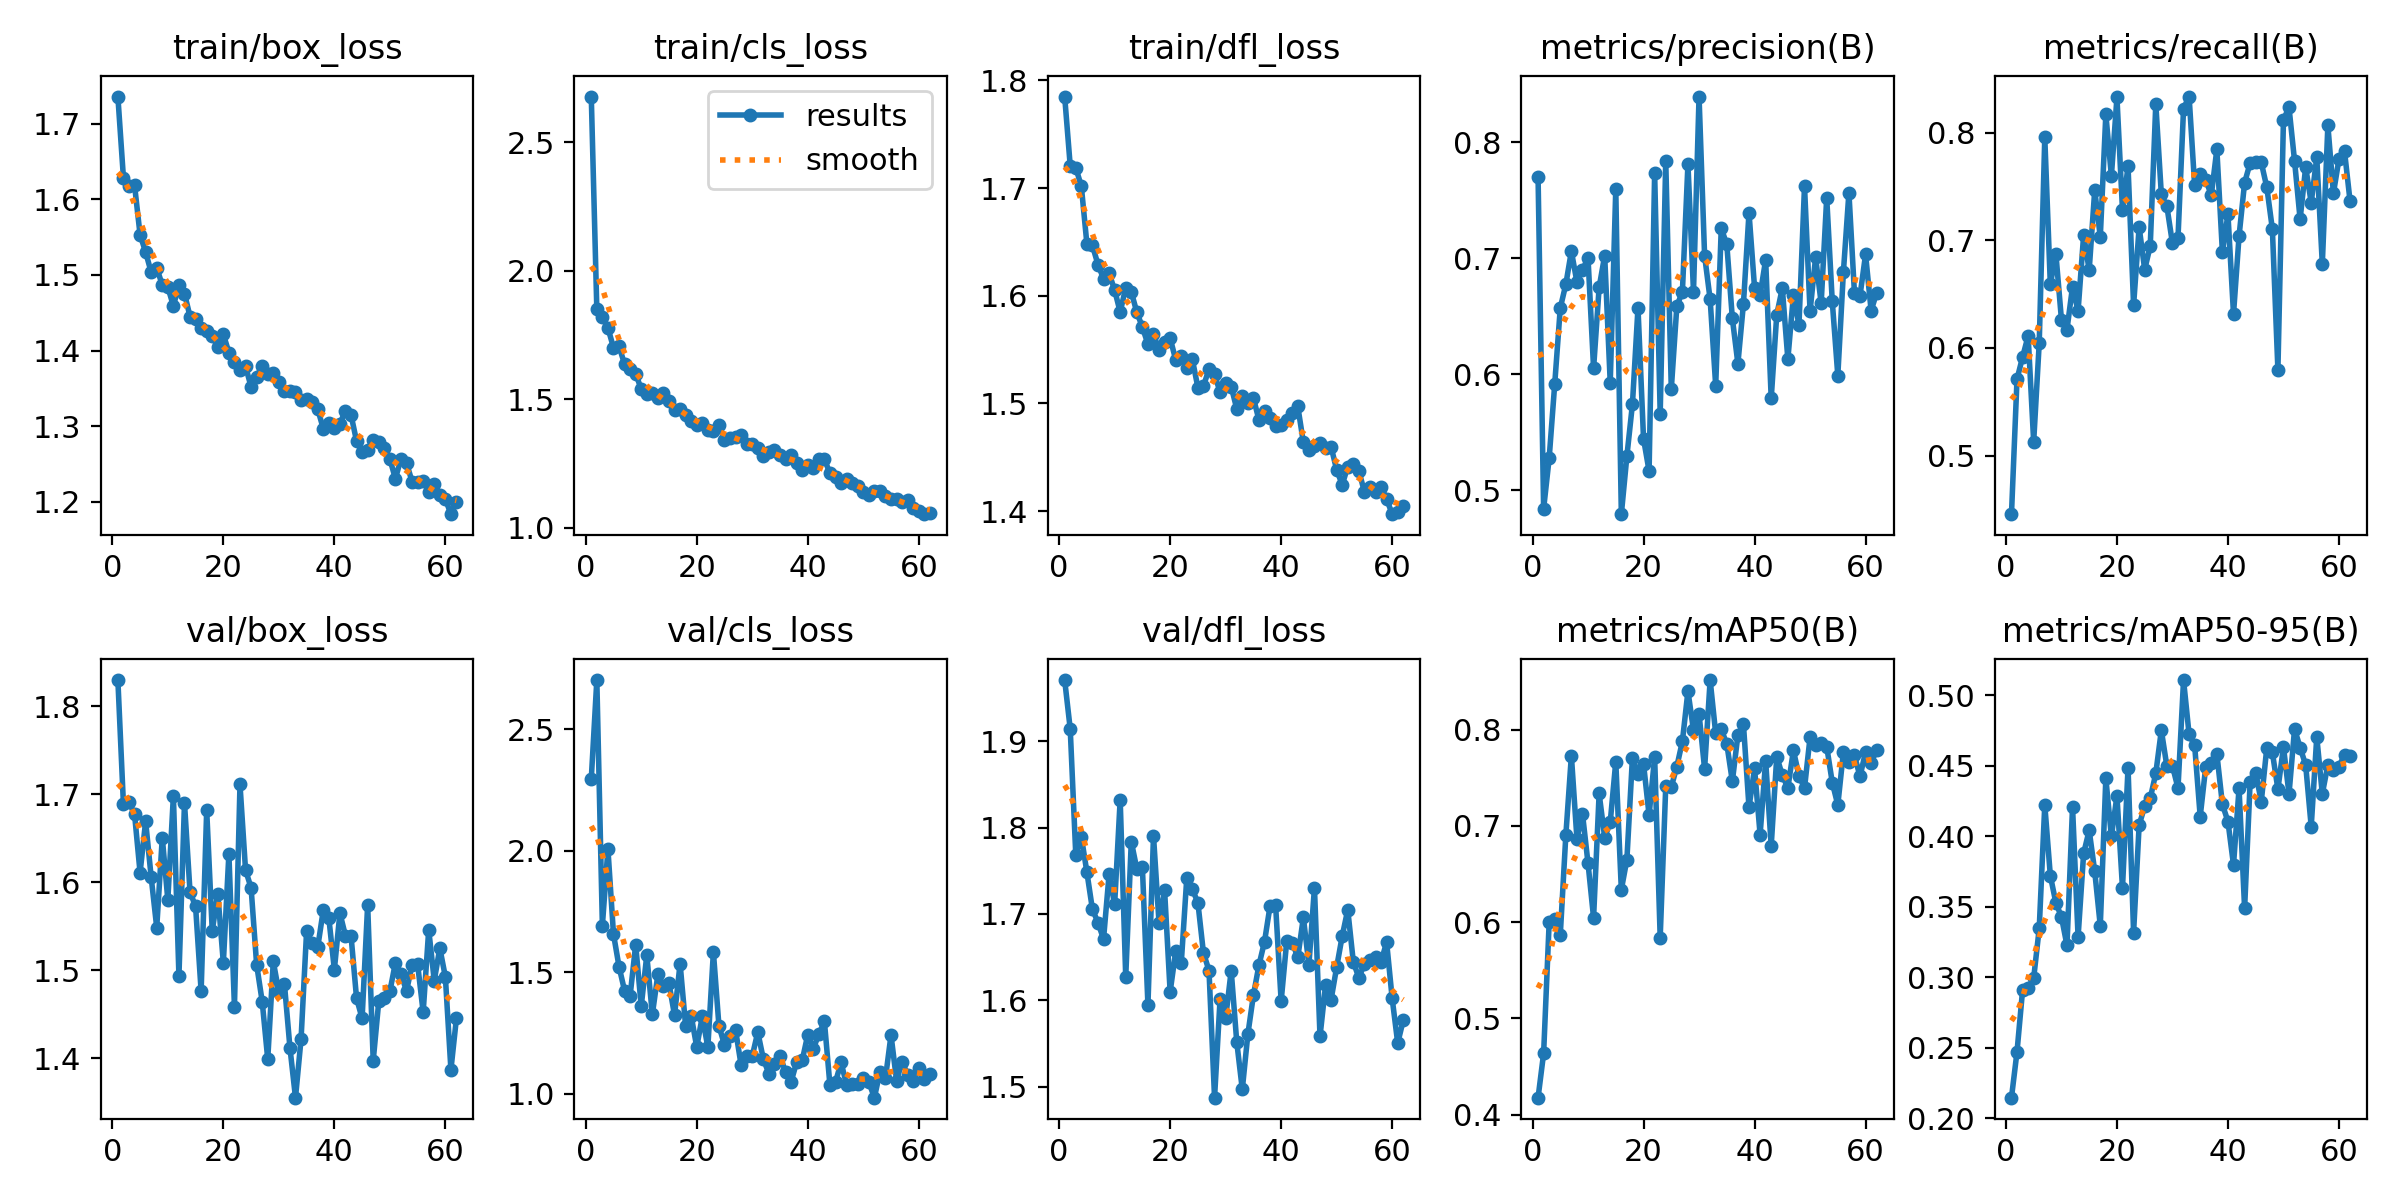

In [ ]:
Image("/content/runs/detect/NEU_Project/YOLOv8s/results.png")

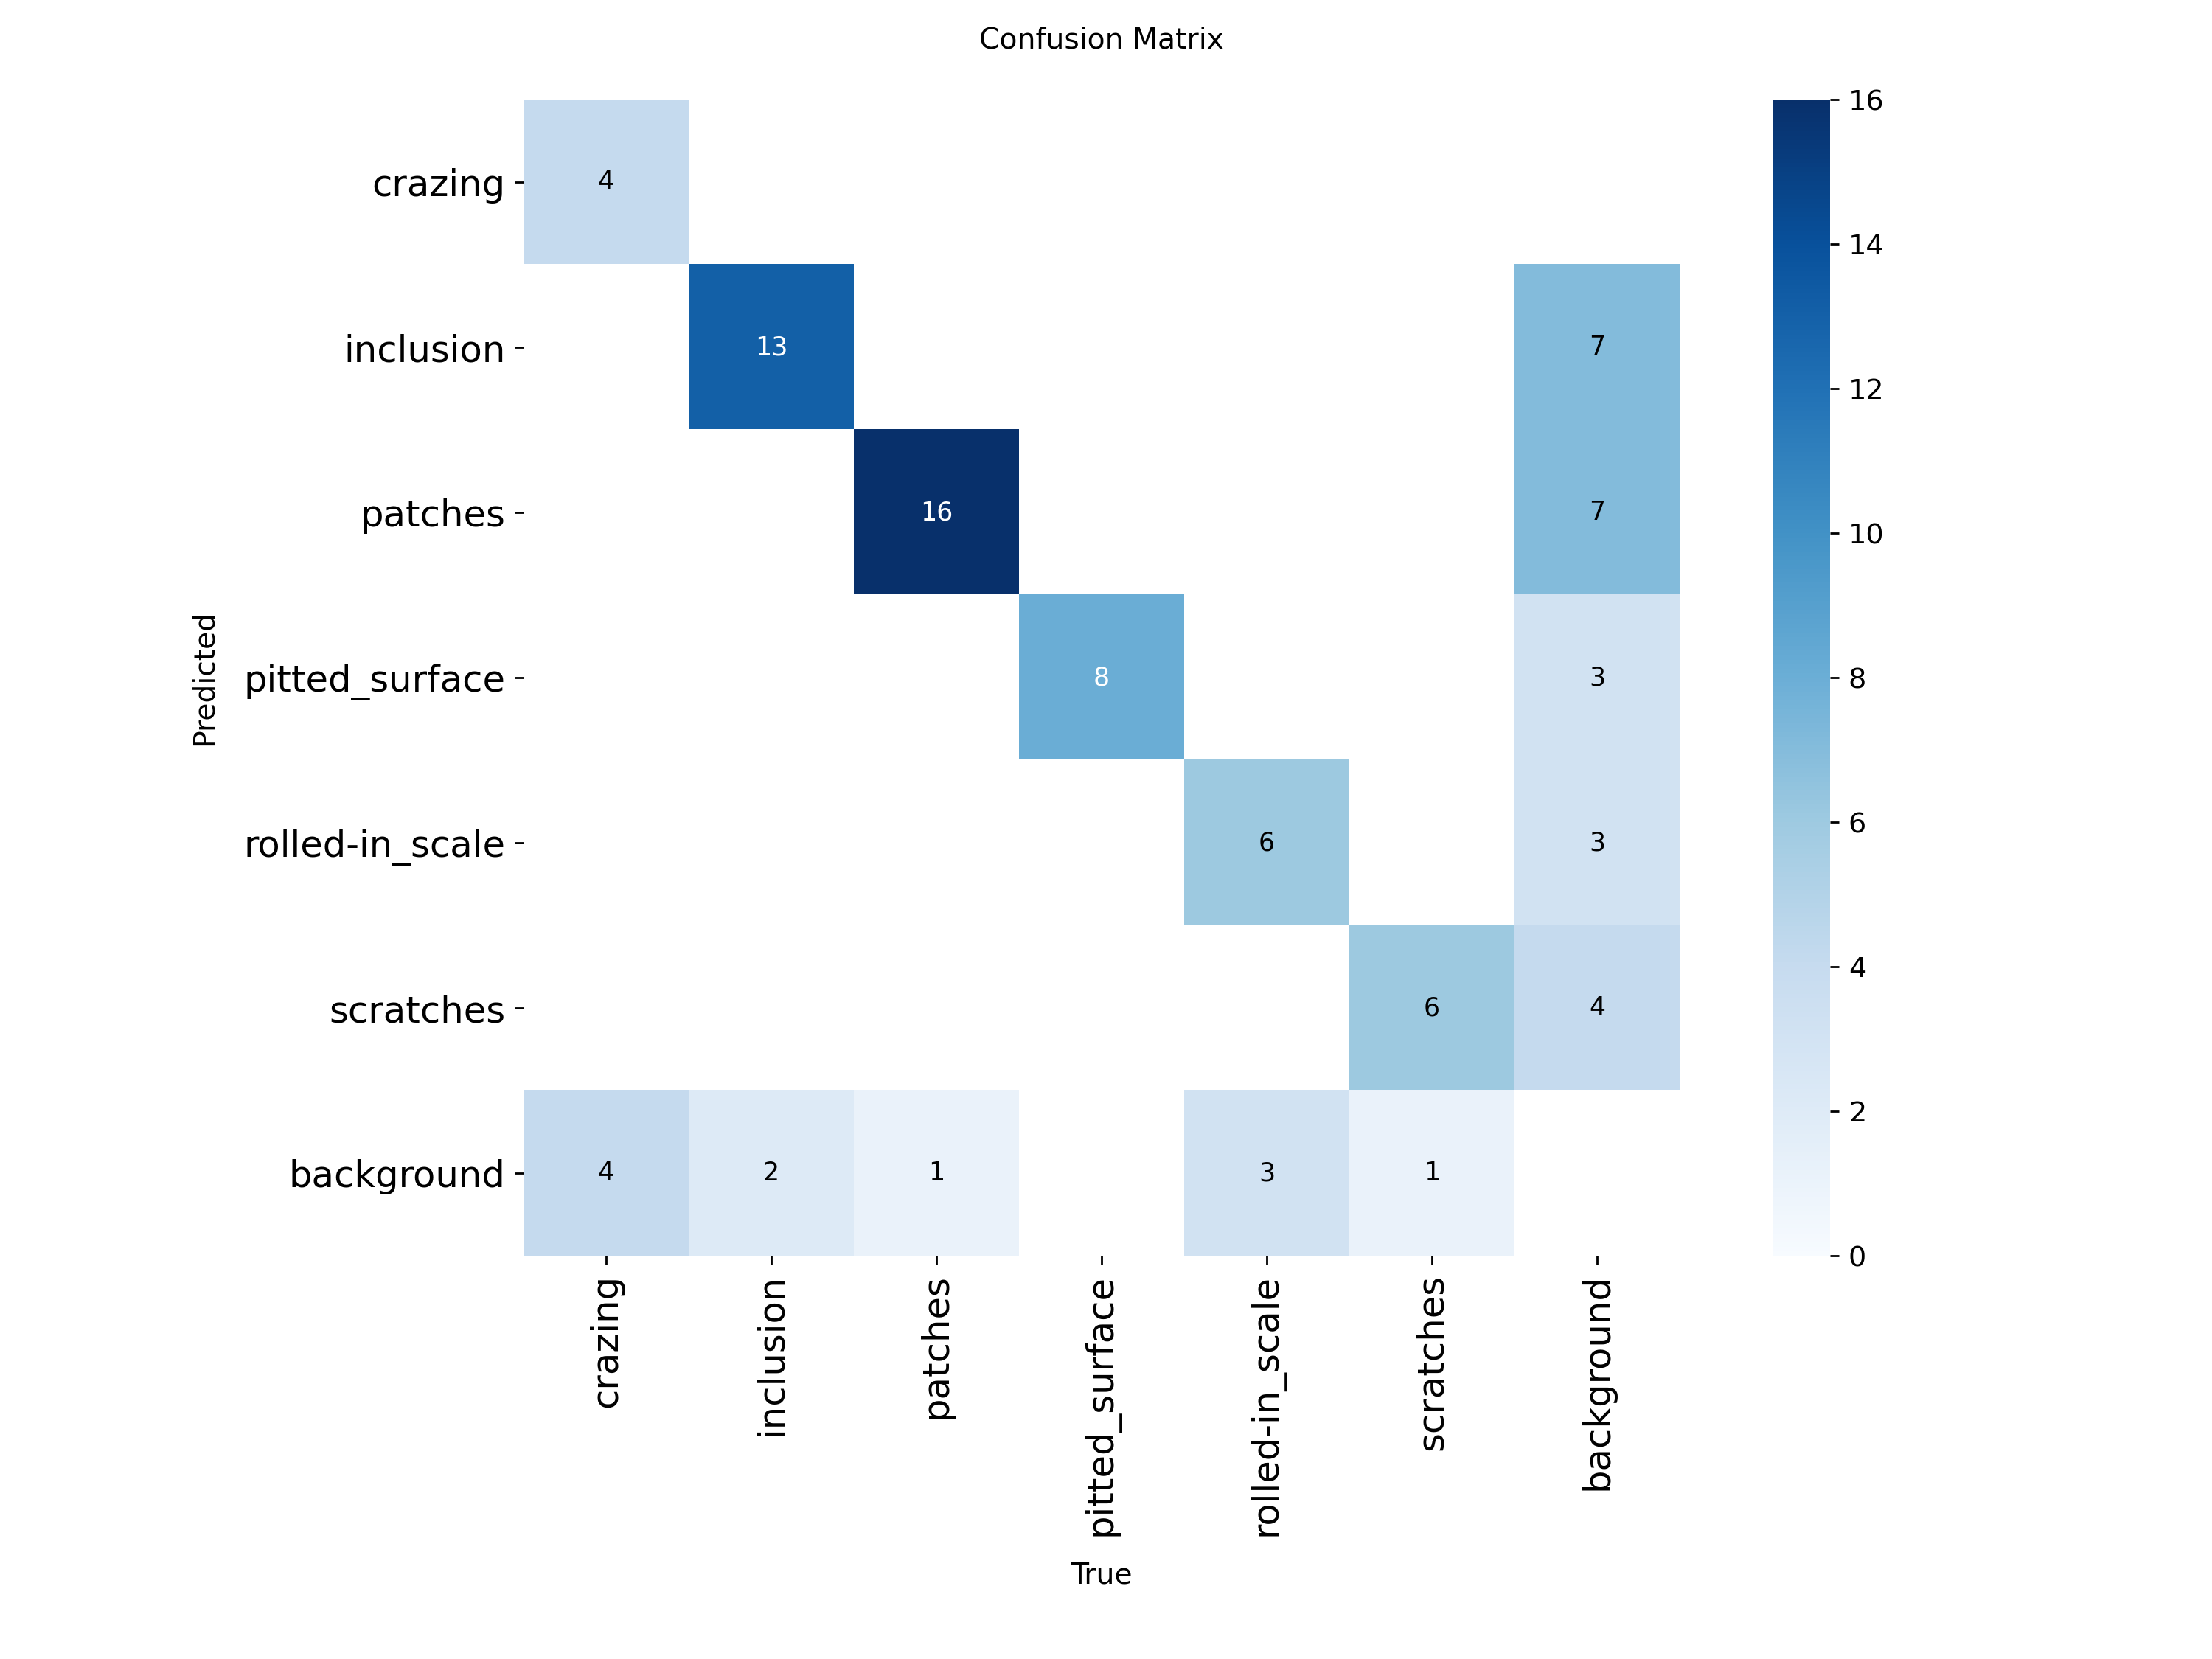

In [ ]:
Image("/content/runs/detect/NEU_Project/YOLOv8s/confusion_matrix.png")

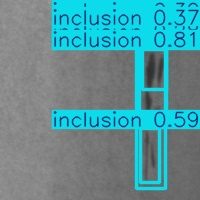

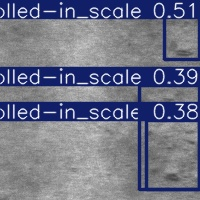

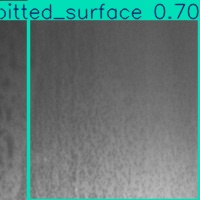

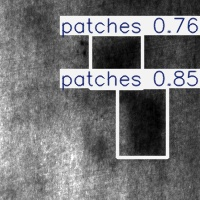

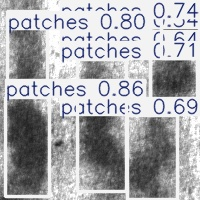

In [ ]:
preds = glob.glob("/content/runs/detect/predict/*.jpg")

for img in preds[:5]:
    display(Image(filename=img))

In [ ]:
files.download("/content/runs/detect/NEU_Project/YOLOv8s/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>